<a href="https://colab.research.google.com/github/ARPUTHAMARY/PrecisionHeart/blob/main/Preprocessing_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lightgbm scikit-learn seaborn matplotlib pandas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    brier_score_loss
)
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

import lightgbm as lgb

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


In [ ]:
DATA_URL = "https://raw.githubusercontent.com/rikhuijzer/heart-disease-dataset/main/heart-disease-dataset.csv"
df = pd.read_csv(DATA_URL)

print("Shape:", df.shape)
display(df.head())
display(df.describe(include="all"))
df.info()


Shape: (1190, 12)


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0.0


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   float64
 1   sex                  1190 non-null   float64
 2   chest_pain_type      1190 non-null   float64
 3   resting_bp_s         1190 non-null   float64
 4   cholesterol          1190 non-null   float64
 5   fasting_blood_sugar  1190 non-null   float64
 6   resting_ecg          1190 non-null   float64
 7   max_heart_rate       1190 non-null   float64
 8   exercise_angina      1190 non-null   float64
 9   oldpeak              1190 non-null   float64
 10  st_slope             1190 non-null   float64
 11  target               1190 non-null   float64
dtypes: float64(12)
memory usage: 111.7 KB


In [ ]:
# Example: drop exact duplicate rows if any
df = df.drop_duplicates()

# Identify target; adjust name if your CSV uses a different label
target_col = "target"  # change if different in your file
assert target_col in df.columns, "Update target_col to the correct target name."

# Handle missing values: simple strategy (can be replaced by more elaborate imputation)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

# Numeric: fill with median
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

# Categorical: fill with mode, then one-hot encode
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

print("Final feature shape:", X.shape)




Final feature shape: (918, 11)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Class distribution (train):")
print(y_train.value_counts(normalize=True))


Train shape: (734, 11) Test shape: (184, 11)
Class distribution (train):
target
1.0    0.553134
0.0    0.446866
Name: proportion, dtype: float64


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = {cls: w for cls, w in zip(classes, class_weights_array)}
class_weight_dict


{np.float64(0.0): np.float64(1.1189024390243902),
 np.float64(1.0): np.float64(0.9039408866995073)}

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]
input_dim

11

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
class AttentionMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], dropout=0.2):
        super().__init__()
        # Feature-wise attention vector
        self.attention = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, input_dim),
            nn.Sigmoid()  # attention weights in [0, 1]
        )
        # MLP backbone
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (batch_size, input_dim)
        attn = self.attention(x)       # feature-wise gates
        x_attn = x * attn              # apply attention
        logits = self.mlp(x_attn)
        return logits.squeeze(-1)      # raw logits

a_mlp = AttentionMLP(input_dim=input_dim).to(device)
a_mlp


AttentionMLP(
  (attention): Sequential(
    (0): Linear(in_features=11, out_features=11, bias=True)
    (1): ReLU()
    (2): Linear(in_features=11, out_features=11, bias=True)
    (3): Sigmoid()
  )
  (mlp): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [ ]:

# Convert data to tensors
Xtr_t = torch.tensor(X_train_scaled, dtype=torch.float32)
ytr_t = torch.tensor(y_train.values, dtype=torch.float32)
Xte_t = torch.tensor(X_test_scaled, dtype=torch.float32)
yte_t = torch.tensor(y_test.values, dtype=torch.float32)

train_ds = TensorDataset(Xtr_t, ytr_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

# Map sklearn class weights to tensors
pos_weight = torch.tensor(class_weight_dict.get(1, 1.0) / class_weight_dict.get(0, 1.0))
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

optimizer = optim.Adam(a_mlp.parameters(), lr=1e-3)
epochs = 40

a_mlp.to(device)
a_mlp.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = a_mlp(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_loader.dataset)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

Epoch 5/40 - Loss: 0.4710
Epoch 10/40 - Loss: 0.3321
Epoch 15/40 - Loss: 0.3101
Epoch 20/40 - Loss: 0.2962
Epoch 25/40 - Loss: 0.2849
Epoch 30/40 - Loss: 0.2641
Epoch 35/40 - Loss: 0.2637
Epoch 40/40 - Loss: 0.2507


In [ ]:
a_mlp.eval()
with torch.no_grad():
    logits_test = a_mlp(Xte_t.to(device)).cpu().numpy()
    prob_test_amlp = 1 / (1 + np.exp(-logits_test))

pred_test_amlp = (prob_test_amlp >= 0.5).astype(int)

acc_amlp = accuracy_score(y_test, pred_test_amlp)
auc_amlp = roc_auc_score(y_test, prob_test_amlp)
brier_amlp = brier_score_loss(y_test, prob_test_amlp)

print(f"A-MLP Accuracy: {acc_amlp:.4f}")
print(f"A-MLP AUC: {auc_amlp:.4f}")
print(f"A-MLP Brier score: {brier_amlp:.4f}")

A-MLP Accuracy: 0.8967
A-MLP AUC: 0.9267
A-MLP Brier score: 0.0914


In [ ]:
# Map class weights to LightGBM 'scale_pos_weight'
# For binary labels {0,1}, scale_pos_weight ~ w_pos / w_neg
w_neg = class_weight_dict.get(0, 1.0)
w_pos = class_weight_dict.get(1, 1.0)
scale_pos_weight = w_pos / w_neg

# Example: no constraints; replace with a list of -1/0/1 per feature as needed
monotone_constraints = [0] * X_train.shape[1]

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_valid = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

lgb_params = {
    "objective": "binary",
    "metric": ["binary_logloss", "auc"],
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "scale_pos_weight": scale_pos_weight,
    "monotone_constraints": monotone_constraints,
    "verbose": -1,
}

evals_result = {}
gbm = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    callbacks=[lgb.record_evaluation(evals_result), lgb.early_stopping(50)] # Corrected: early_stopping_rounds moved to callbacks
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[73]	train's binary_logloss: 0.193173	train's auc: 0.987039	valid's binary_logloss: 0.32275	valid's auc: 0.930297


In [ ]:
prob_test_lgb = gbm.predict(X_test, num_iteration=gbm.best_iteration)
pred_test_lgb = (prob_test_lgb >= 0.5).astype(int)

acc_lgb = accuracy_score(y_test, pred_test_lgb)
auc_lgb = roc_auc_score(y_test, prob_test_lgb)
brier_lgb = brier_score_loss(y_test, prob_test_lgb)

print(f"LightGBM Accuracy: {acc_lgb:.4f}")
print(f"LightGBM AUC: {auc_lgb:.4f}")
print(f"LightGBM Brier score: {brier_lgb:.4f}")


LightGBM Accuracy: 0.8859
LightGBM AUC: 0.9303
LightGBM Brier score: 0.0930


In [ ]:
# Use training data for meta-learner via internal cross-validation
# First, get out-of-fold probabilities for A-MLP and LightGBM on train data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

meta_train = np.zeros((X_train.shape[0], 2))
meta_test = np.zeros((X_test.shape[0], 2))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    # Split fold data
    X_tr_fold = X_train.iloc[tr_idx]
    y_tr_fold = y_train.iloc[tr_idx]
    X_val_fold = X_train.iloc[val_idx]
    # Scale for A-MLP
    X_tr_fold_scaled = scaler.fit_transform(X_tr_fold)
    X_val_fold_scaled = scaler.transform(X_val_fold)

    # Re-init and train a smaller A-MLP per fold (for meta-features)
    a_mlp_fold = AttentionMLP(input_dim=input_dim).to(device)
    optimizer_fold = optim.Adam(a_mlp_fold.parameters(), lr=1e-3)
    train_ds_fold = TensorDataset(
        torch.tensor(X_tr_fold_scaled, dtype=torch.float32),
        torch.tensor(y_tr_fold.values, dtype=torch.float32)
    )
    loader_fold = DataLoader(train_ds_fold, batch_size=128, shuffle=True)

    a_mlp_fold.train()
    for epoch in range(10):  # fewer epochs for meta-features
        for xb, yb in loader_fold:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer_fold.zero_grad()
            logits = a_mlp_fold(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer_fold.step()

    a_mlp_fold.eval()
    with torch.no_grad():
        val_scaled_t = torch.tensor(X_val_fold_scaled, dtype=torch.float32).to(device)
        logits_val = a_mlp_fold(val_scaled_t).cpu().numpy()
        prob_val_amlp = 1 / (1 + np.exp(-logits_val))

    # LightGBM per fold
    lgb_train_fold = lgb.Dataset(X_tr_fold, label=y_tr_fold)
    gbm_fold = lgb.train(
        lgb_params,
        lgb_train_fold,
        num_boost_round=200,
        callbacks=[lgb.log_evaluation(period=0)] # Corrected: verbose_eval moved to callbacks
    )
    prob_val_lgb = gbm_fold.predict(X_val_fold)

    # Store meta features (order: [A-MLP prob, LGB prob])
    meta_train[val_idx, 0] = prob_val_amlp
    meta_train[val_idx, 1] = prob_val_lgb

# For test meta-features, use full models already trained above
meta_test[:, 0] = prob_test_amlp
meta_test[:, 1] = prob_test_lgb

print("Meta-train shape:", meta_train.shape)
print("Meta-test shape:", meta_test.shape)

Meta-train shape: (734, 2)
Meta-test shape: (184, 2)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Base logistic regression for stacking
meta_lr = LogisticRegression()
# Calibrated meta-learner (Platt scaling)
meta_clf = CalibratedClassifierCV(
    estimator=meta_lr, # Changed 'base_estimator' to 'estimator'
    method="sigmoid",
    cv=5
)

meta_clf.fit(meta_train, y_train)
prob_test_meta = meta_clf.predict_proba(meta_test)[:, 1]
pred_test_meta = (prob_test_meta >= 0.5).astype(int)

acc_meta = accuracy_score(y_test, pred_test_meta)
auc_meta = roc_auc_score(y_test, prob_test_meta)
brier_meta = brier_score_loss(y_test, prob_test_meta)

print(f"Meta-ensemble Accuracy: {acc_meta:.4f}")
print(f"Meta-ensemble AUC: {auc_meta:.4f}")
print(f"Meta-ensemble Brier score: {brier_meta:.4f}")

Meta-ensemble Accuracy: 0.9022
Meta-ensemble AUC: 0.9323
Meta-ensemble Brier score: 0.0833


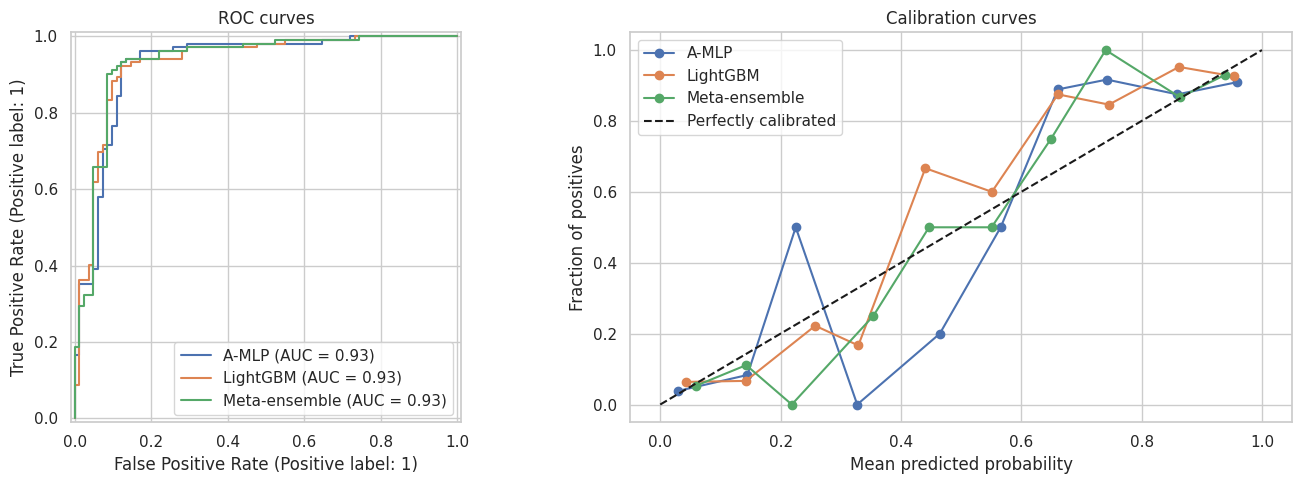

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
ax = axes[0]
RocCurveDisplay.from_predictions(y_test, prob_test_amlp, name="A-MLP", ax=ax)
RocCurveDisplay.from_predictions(y_test, prob_test_lgb, name="LightGBM", ax=ax)
RocCurveDisplay.from_predictions(y_test, prob_test_meta, name="Meta-ensemble", ax=ax)
ax.set_title("ROC curves")

# Calibration curves
ax = axes[1]
for probs, name in [
    (prob_test_amlp, "A-MLP"),
    (prob_test_lgb, "LightGBM"),
    (prob_test_meta, "Meta-ensemble")
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label=name)

ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curves")
ax.legend()

plt.tight_layout()
plt.show()


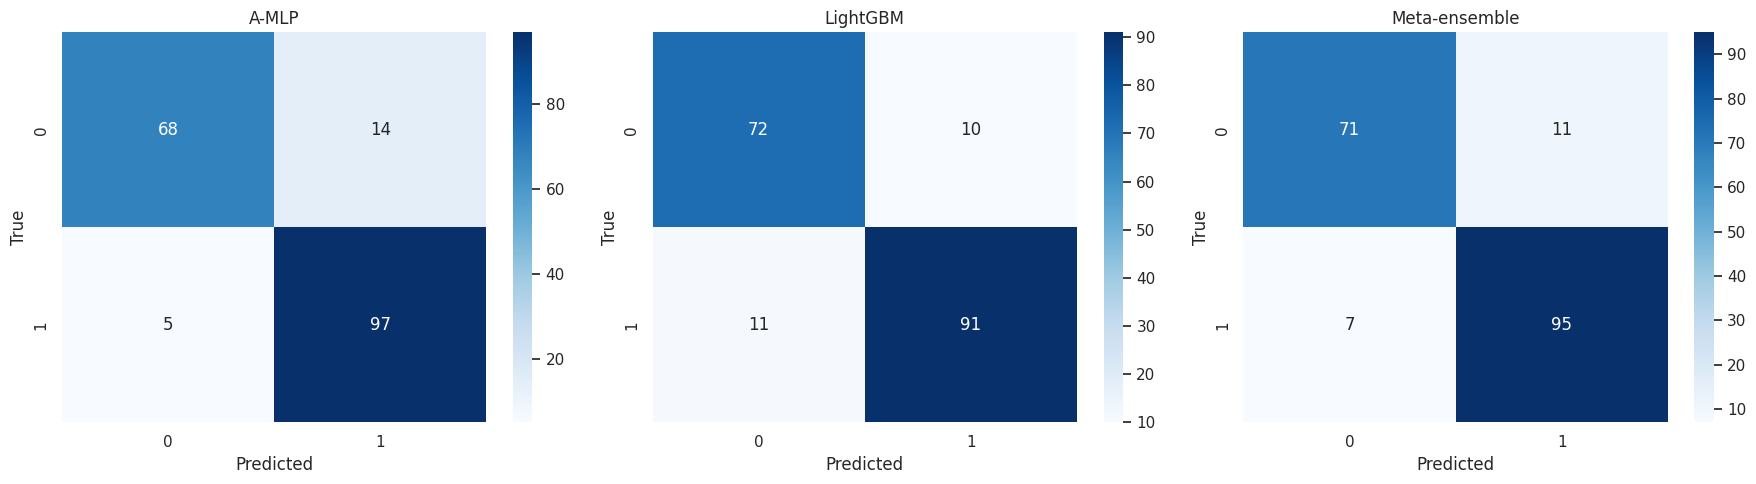

Meta-ensemble classification report:
              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89        82
         1.0       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



In [ ]:
def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_cm(y_test, pred_test_amlp, "A-MLP", axes[0])
plot_cm(y_test, pred_test_lgb, "LightGBM", axes[1])
plot_cm(y_test, pred_test_meta, "Meta-ensemble", axes[2])
plt.tight_layout()
plt.show()

print("Meta-ensemble classification report:")
print(classification_report(y_test, pred_test_meta))

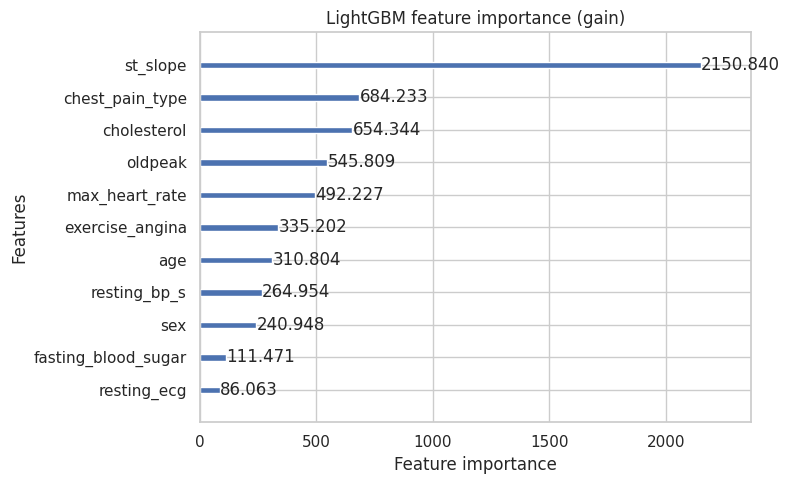

,feature,avg_attention_weight
7,max_heart_rate,0.593967
1,sex,0.590582
5,fasting_blood_sugar,0.579632
9,oldpeak,0.579523
2,chest_pain_type,0.575313
8,exercise_angina,0.539434
0,age,0.526324
10,st_slope,0.525314
3,resting_bp_s,0.511236
6,resting_ecg,0.511157


In [ ]:
# LightGBM feature importance
lgb.plot_importance(gbm, max_num_features=20, importance_type="gain")
plt.title("LightGBM feature importance (gain)")
plt.tight_layout()
plt.show()

# Extract average attention weights over test data
a_mlp.eval()
with torch.no_grad():
    Xte_t = Xte_t.to(device)
    attn_layer = a_mlp.attention(Xte_t).cpu().numpy()
avg_attn = attn_layer.mean(axis=0)

attn_df = pd.DataFrame({
    "feature": X.columns,
    "avg_attention_weight": avg_attn
}).sort_values("avg_attention_weight", ascending=False)

attn_df.head(20)
